In [1]:
import h5py
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
import torch.optim as optim

/Users/arpinejanunts/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [1]:
base = r"/Users/arpinejanunts/Desktop/Capstone/"

TRAIN_PATH = base + "5x127x127_training_with_morphology.hdf5"
VAL_PATH   = base + "5x127x127_validation_with_morphology.hdf5"
TEST_PATH  = base + "5x127x127_testing_with_morphology.hdf5"

EXCLUDE = {
    'image',                   
    'specz_redshift',           
    'specz_redshift_err',       
    'specz_flag_homogeneous',  
}

def load_split(path):
    with h5py.File(path, "r") as f:
        data = {}
        for key in sorted(f.keys()):
            if key in EXCLUDE:
                continue
            arr = f[key][:]
            if arr.ndim == 1:
                data[key] = arr
            elif arr.ndim == 2:
                for i in range(arr.shape[1]):
                    data[f"{key}_{i}"] = arr[:, i]

        label = f['specz_redshift'][:].astype(np.float64)
        flag  = f['specz_flag_homogeneous'][:].astype(bool)

    df = pd.DataFrame(data)
    df['specz_redshift'] = label
    df['specz_flag_homogeneous'] = flag

    df = df[df['specz_flag_homogeneous'] == True].reset_index(drop=True)
    df = df.drop(columns=['specz_flag_homogeneous'])

    return df

df_train = load_split(TRAIN_PATH)
df_val   = load_split(VAL_PATH)
df_test  = load_split(TEST_PATH)

print(f"Train : {df_train.shape}")
print(f"Val   : {df_val.shape}")
print(f"Test  : {df_test.shape}")
print(f"\nColumns ({len(df_train.columns)}):\n{list(df_train.columns)}")
print(f"\nDtypes:\n{df_train.dtypes}")
print(f"\nLabel range — min: {df_train['specz_redshift'].min():.4f}, "
      f"max: {df_train['specz_redshift'].max():.4f}, "
      f"mean: {df_train['specz_redshift'].mean():.4f}")


/Users/arpinejanunts/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Train : (204573, 90)
Val   : (40914, 90)
Test  : (40914, 90)

Columns (90):
['coord_0', 'dec', 'g_central_image_pop_10px_rad', 'g_central_image_pop_15px_rad', 'g_central_image_pop_5px_rad', 'g_cmodel_mag', 'g_cmodel_magsigma', 'g_ellipticity', 'g_half_light_radius', 'g_isophotal_area', 'g_major_axis', 'g_minor_axis', 'g_peak_surface_brightness', 'g_petro_rad', 'g_pos_angle', 'g_sersic_index', 'i_central_image_pop_10px_rad', 'i_central_image_pop_15px_rad', 'i_central_image_pop_5px_rad', 'i_cmodel_mag', 'i_cmodel_magsigma', 'i_ellipticity', 'i_half_light_radius', 'i_isophotal_area', 'i_major_axis', 'i_minor_axis', 'i_peak_surface_brightness', 'i_petro_rad', 'i_pos_angle', 'i_sersic_index', 'object_id', 'r_central_image_pop_10px_rad', 'r_central_image_pop_15px_rad', 'r_central_image_pop_5px_rad', 'r_cmodel_mag', 'r_cmodel_magsigma', 'r_ellipticity', 'r_half_light_radius', 'r_isophotal_area', 'r_major_axis', 'r_minor_axis', 'r_peak_surface_brightness', 'r_petro_rad', 'r_pos_angle', 'r_sers

In [3]:
df_train

,coord_0,dec,g_central_image_pop_10px_rad,g_central_image_pop_15px_rad,g_central_image_pop_5px_rad,g_cmodel_mag,g_cmodel_magsigma,g_ellipticity,g_half_light_radius,g_isophotal_area,...,z_ellipticity,z_half_light_radius,z_isophotal_area,z_major_axis,z_minor_axis,z_peak_surface_brightness,z_petro_rad,z_pos_angle,z_sersic_index,specz_redshift
0,"b'(179028.65625, 99644.3671875, -23767.86328125)'",-6.616883,1,1,1,20.162785,0.002381,0.026,2.085,177.0,...,0.076,2.186,127.0,2.112,1.951,-8.0189,4.62,63.61,1.146,2.17865
1,"b'(178895.09375, 99811.6484375, -24069.6933593...",-6.701294,1,1,1,20.320715,0.005252,0.143,5.986,327.0,...,0.129,6.270,547.0,5.043,4.393,-7.6611,6.60,74.63,1.576,0.43602
2,"b'(178918, 99992.578125, -23130.162109375)'",-6.438588,1,1,1,21.629736,0.013312,0.068,7.286,162.0,...,0.082,6.687,611.0,5.370,4.932,-7.2715,7.26,83.77,2.096,0.56511
3,"b'(179111.03125, 99659.84375, -23072.220703125)'",-6.422391,1,1,1,21.448307,0.004646,0.012,2.108,109.0,...,0.023,2.966,121.0,2.323,2.269,-6.8408,6.60,29.82,1.943,0.84550
4,"b'(178849.21875, 99990.828125, -23663.556640625)'",-6.587715,1,1,1,21.827169,0.010504,0.150,4.552,113.0,...,0.256,5.264,401.0,4.652,3.463,-7.2982,7.26,66.69,2.187,0.51283
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204568,"b'(-103042.1796875, -68623.8203125, 164979.546...",53.115152,1,1,1,22.603470,0.013377,0.127,5.140,157.0,...,0.097,3.910,199.0,3.176,2.869,-6.3175,5.94,52.46,1.300,0.72650
204569,"b'(-102705.109375, -69098.7890625, 164991.4843...",53.120677,1,2,1,21.211262,0.002013,0.050,2.523,216.0,...,0.031,2.441,95.0,2.049,1.985,-6.3903,5.28,86.33,0.955,1.86393
204570,"b'(-102906.5, -68952.8125, 164927.046875)'",53.090862,1,1,1,19.315403,0.001800,0.133,6.529,864.0,...,0.121,6.587,1361.0,6.917,6.083,-8.4032,5.28,-48.55,1.832,0.24194
204571,"b'(-102564.9296875, -69022.4609375, 165110.578...",53.175836,1,1,1,22.623613,0.010091,0.298,4.448,144.0,...,0.292,4.161,106.0,3.060,2.166,-4.6701,7.26,76.00,0.571,0.77584


# Feature Importance and Selection 

In [5]:
feature_cols  = [c for c in df_train.columns if c != 'specz_redshift']
numeric_cols  = df_train[feature_cols].select_dtypes(include=[np.number]).columns.tolist()

corr_with_label = (
    df_train[numeric_cols + ['specz_redshift']]
    .corr()['specz_redshift']
    .drop('specz_redshift')
    .abs()
    .sort_values(ascending=False)
)

print(f"Total numeric features: {len(numeric_cols)}")
print(f"\nTop 20 features most correlated with specz_redshift:")
print(corr_with_label.head(20).to_string())

print(f"\nBottom 10 features least correlated with specz_redshift:")
print(corr_with_label.tail(10).to_string())


Total numeric features: 87

Top 20 features most correlated with specz_redshift:
i_major_axis           0.577381
z_major_axis           0.564428
i_minor_axis           0.563103
r_major_axis           0.555023
y_half_light_radius    0.551215
y_major_axis           0.550371
z_minor_axis           0.549891
i_half_light_radius    0.549300
z_half_light_radius    0.547114
r_half_light_radius    0.546777
y_cmodel_mag           0.542015
r_minor_axis           0.540682
y_minor_axis           0.539531
z_cmodel_mag           0.536351
g_half_light_radius    0.535512
i_cmodel_mag           0.526626
i_isophotal_area       0.520295
specz_mag_i            0.514988
z_isophotal_area       0.505264
g_major_axis           0.504444

Bottom 10 features least correlated with specz_redshift:
g_pos_angle                     0.008036
i_central_image_pop_5px_rad     0.005939
y_coord_x_1                     0.004103
x_coord_x_1                     0.003402
x_coord_y_0                     0.003339
y_coord_y_0     

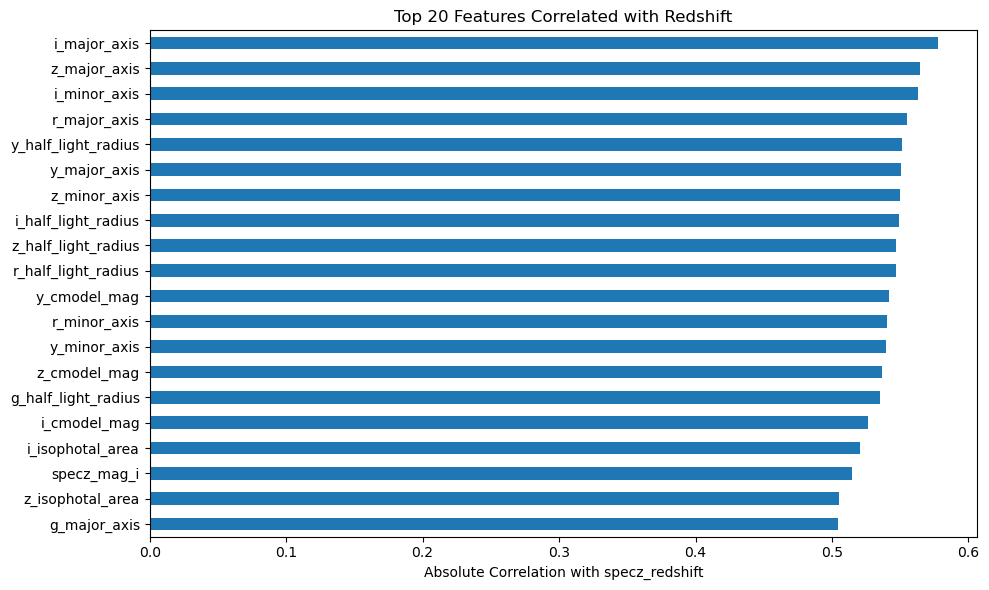

In [6]:
top_n = 20
top_features = corr_with_label.head(top_n)

plt.figure(figsize=(10, 6))
top_features.sort_values().plot(kind='barh')
plt.xlabel('Absolute Correlation with specz_redshift')
plt.title(f'Top {top_n} Features Correlated with Redshift')
plt.tight_layout()
plt.show()


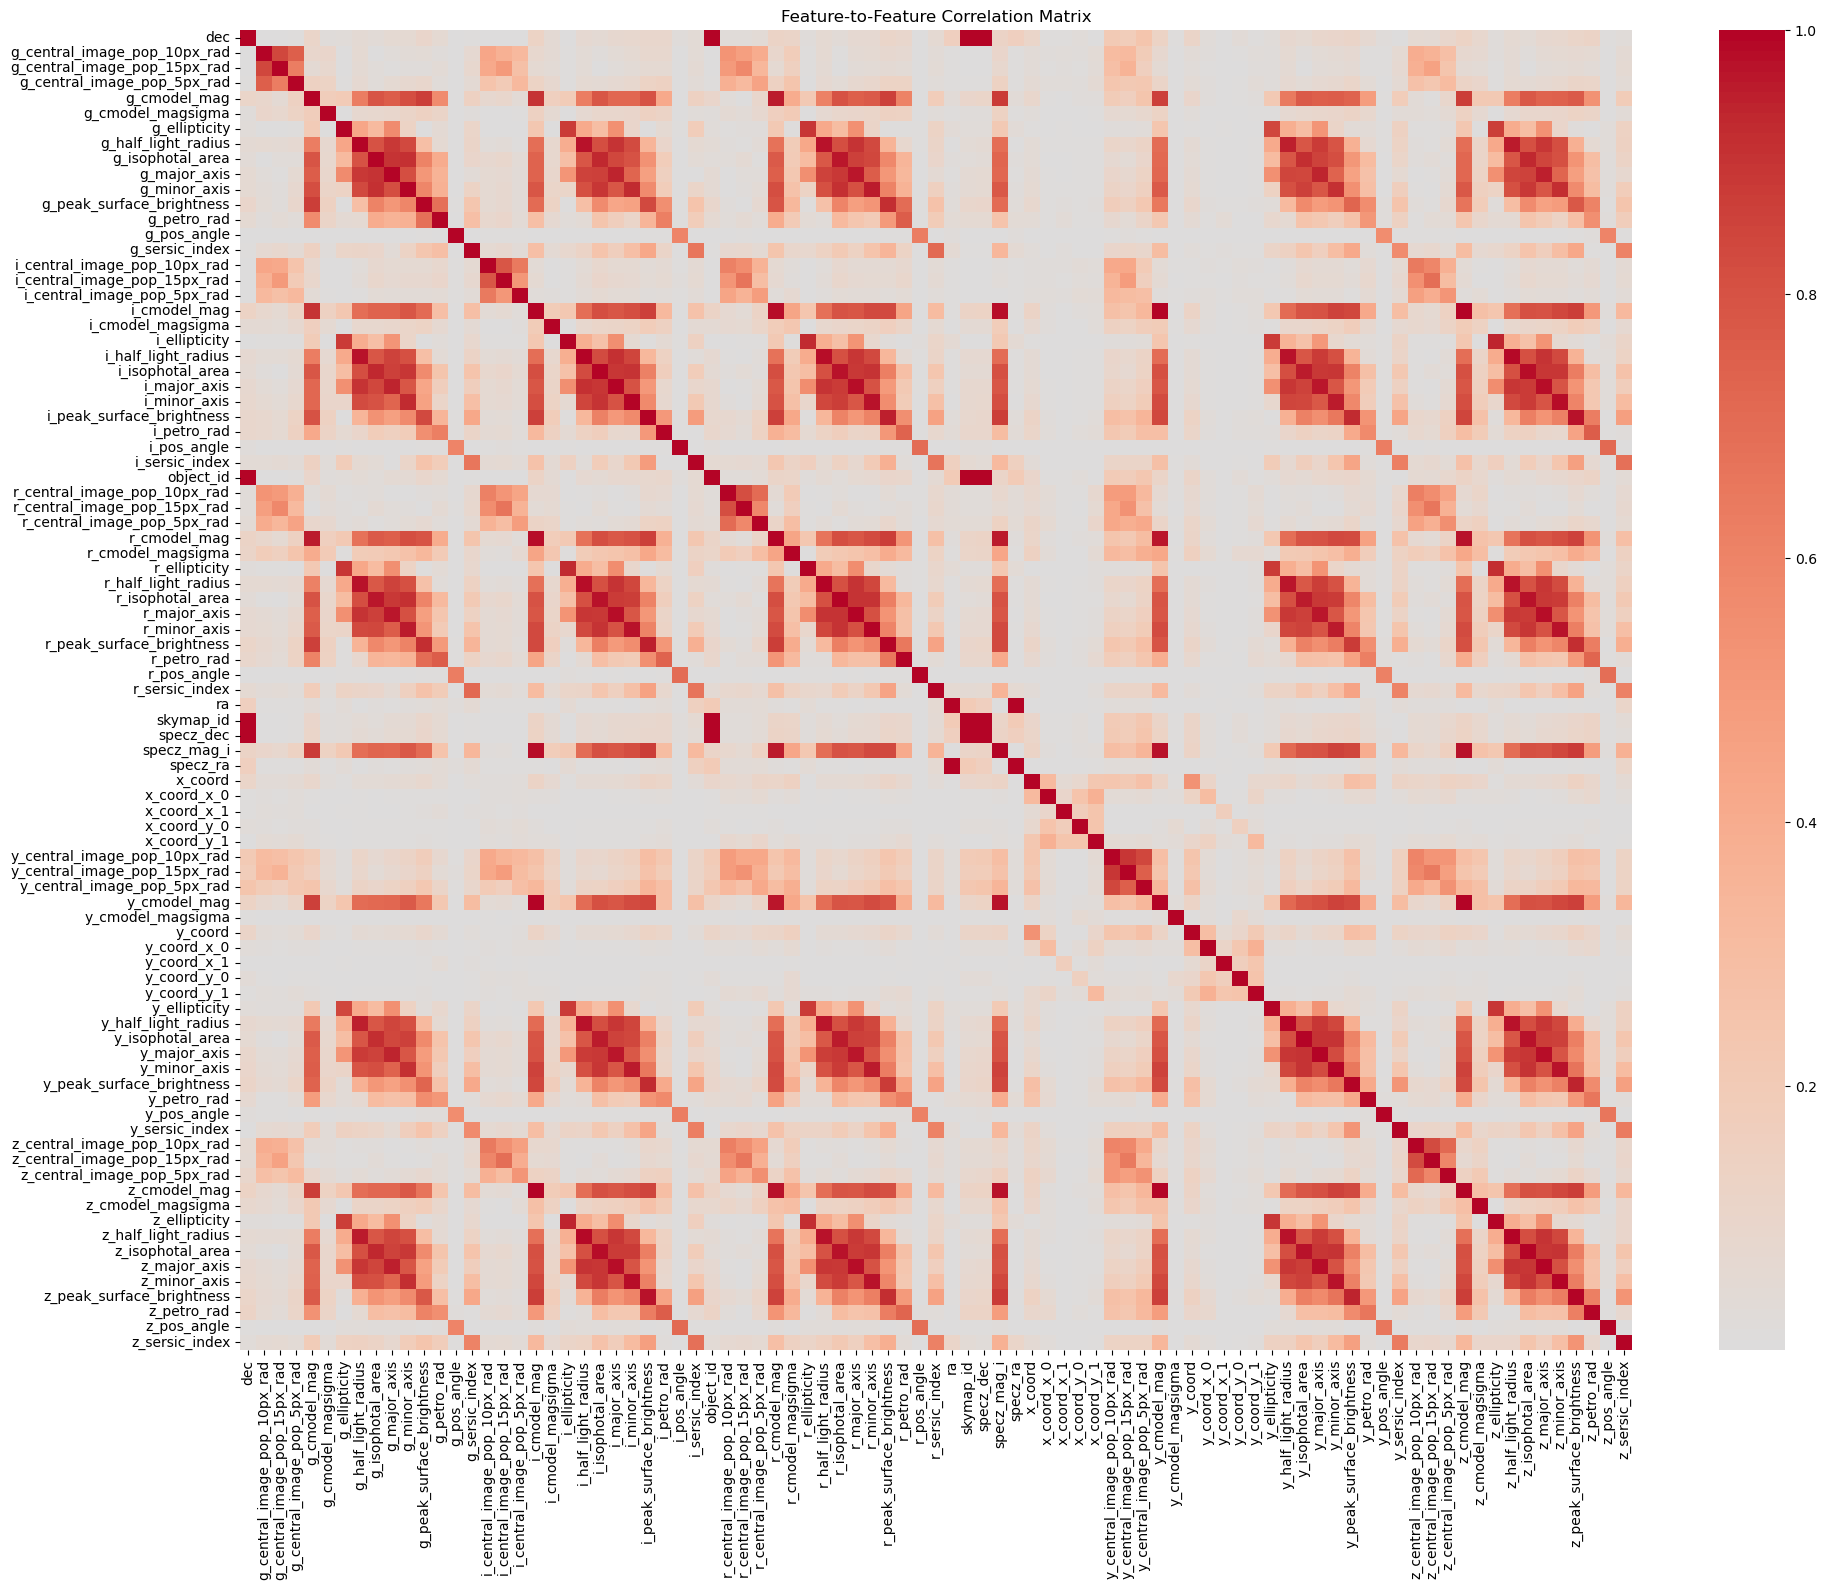

In [7]:
corr_matrix = df_train[numeric_cols].corr().abs()

plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0,
            xticklabels=True, yticklabels=True)
plt.title('Feature-to-Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [8]:
HIGH_CORR   = 0.3   
MEDIUM_CORR = 0.1   
LOW_CORR    = 0.1  

high   = corr_with_label[corr_with_label >= HIGH_CORR]
medium = corr_with_label[(corr_with_label >= MEDIUM_CORR) & (corr_with_label < HIGH_CORR)]
low    = corr_with_label[corr_with_label < LOW_CORR]

print(f"High correlation (>= 0.3):   {len(high)} features")
print(f"Medium correlation (0.1-0.3): {len(medium)} features")
print(f"Low correlation (< 0.1):     {len(low)} features")
print(f"\nHigh correlation features:\n{high.to_string()}")
print(f"\nLow correlation features (likely weak):\n{low.to_string()}")


High correlation (>= 0.3):   31 features
Medium correlation (0.1-0.3): 9 features
Low correlation (< 0.1):     47 features

High correlation features:
i_major_axis           0.577381
z_major_axis           0.564428
i_minor_axis           0.563103
r_major_axis           0.555023
y_half_light_radius    0.551215
y_major_axis           0.550371
z_minor_axis           0.549891
i_half_light_radius    0.549300
z_half_light_radius    0.547114
r_half_light_radius    0.546777
y_cmodel_mag           0.542015
r_minor_axis           0.540682
y_minor_axis           0.539531
z_cmodel_mag           0.536351
g_half_light_radius    0.535512
i_cmodel_mag           0.526626
i_isophotal_area       0.520295
specz_mag_i            0.514988
z_isophotal_area       0.505264
g_major_axis           0.504444
r_isophotal_area       0.496845
g_minor_axis           0.486470
y_isophotal_area       0.485381
r_cmodel_mag           0.476916
g_isophotal_area       0.444069
z_ellipticity          0.380305
i_ellipticity    

In [9]:
REDUNDANCY_THRESHOLD = 0.95

corr_matrix = df_train[numeric_cols].corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

redundant_pairs = [(col, row, upper.loc[row, col])
                   for col in upper.columns
                   for row in upper.index
                   if upper.loc[row, col] >= REDUNDANCY_THRESHOLD]

redundant_pairs = sorted(redundant_pairs, key=lambda x: x[2], reverse=True)

print(f"Redundant feature pairs (correlation >= {REDUNDANCY_THRESHOLD}):")
for f1, f2, corr_val in redundant_pairs:
    print(f"  {f1:45s} <-> {f2:45s}  corr={corr_val:.4f}")

Redundant feature pairs (correlation >= 0.95):
  specz_ra                                      <-> ra                                             corr=1.0000
  specz_dec                                     <-> dec                                            corr=1.0000
  skymap_id                                     <-> object_id                                      corr=1.0000
  specz_dec                                     <-> object_id                                      corr=0.9981
  object_id                                     <-> dec                                            corr=0.9981
  specz_dec                                     <-> skymap_id                                      corr=0.9981
  skymap_id                                     <-> dec                                            corr=0.9981
  z_cmodel_mag                                  <-> y_cmodel_mag                                   corr=0.9968
  z_cmodel_mag                                  <-> i_cmodel_mag 

In [10]:
X_tr = df_train[numeric_cols].values
selector = VarianceThreshold(threshold=0.0)
selector.fit(X_tr)

zero_var = [numeric_cols[i] for i, v in enumerate(selector.variances_) if v == 0]
low_var  = [numeric_cols[i] for i, v in enumerate(selector.variances_) if 0 < v < 1e-5]

print(f"Zero variance features (constant, useless): {zero_var}")
print(f"Near-zero variance features:                {low_var}")


Zero variance features (constant, useless): []
Near-zero variance features:                []


In [11]:
nan_counts = df_train[numeric_cols].isnull().sum()
inf_counts = df_train[numeric_cols].apply(lambda col: np.isinf(col).sum())

problems = pd.DataFrame({
    'nan_count': nan_counts,
    'inf_count': inf_counts,
    'nan_pct':   (nan_counts / len(df_train) * 100).round(2),
}).sort_values('nan_count', ascending=False)

print("Features with missing/infinite values:")
print(problems[problems['nan_count'] + problems['inf_count'] > 0].to_string())

Features with missing/infinite values:
Empty DataFrame
Columns: [nan_count, inf_count, nan_pct]
Index: []


In [12]:
to_drop = set()

to_drop.update(zero_var)

to_drop.update(low.index.tolist())

redundant_to_drop = set([f2 for f1, f2, _ in redundant_pairs])
to_drop.update(redundant_to_drop)

print(f"Dropped due to zero variance:     {len(zero_var)}")
print(f"Dropped due to low correlation:   {len(low.index.tolist())}")
print(f"Dropped due to redundancy:        {len(redundant_to_drop)}")
print(f"\nTotal features to drop: {len(to_drop)}")

final_features = [f for f in numeric_cols if f not in to_drop]
print(f"Features before: {len(numeric_cols)}")
print(f"Features after:  {len(final_features)}")
print(f"\nFinal features to consider:\n{final_features}")


Dropped due to zero variance:     0
Dropped due to low correlation:   47
Dropped due to redundancy:        26

Total features to drop: 69
Features before: 87
Features after:  18

Final features to consider:
['g_ellipticity', 'g_sersic_index', 'i_ellipticity', 'r_cmodel_magsigma', 'r_ellipticity', 'r_peak_surface_brightness', 'y_central_image_pop_10px_rad', 'y_central_image_pop_5px_rad', 'y_ellipticity', 'y_peak_surface_brightness', 'z_cmodel_mag', 'z_cmodel_magsigma', 'z_ellipticity', 'z_half_light_radius', 'z_isophotal_area', 'z_major_axis', 'z_minor_axis', 'z_peak_surface_brightness']


In [13]:
X_train_final = df_train[final_features].values.astype(np.float64)
X_val_final   = df_val[final_features].values.astype(np.float64)
y_train_final = df_train['specz_redshift'].values
y_val_final   = df_val['specz_redshift'].values

In [14]:
dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(X_train_final, y_train_final)

y_pred_val = dt.predict(X_val_final)

mse  = mean_squared_error(y_val_final, y_pred_val)
mae  = mean_absolute_error(y_val_final, y_pred_val)
delta_z = np.abs(y_pred_val - y_val_final) / (1 + y_val_final)
outlier_rate = np.mean(delta_z > 0.15) * 100

print(f"Decision Tree — MSE: {mse:.4f} | MAE: {mae:.4f} | Outlier Rate: {outlier_rate:.2f}%")

Decision Tree — MSE: 0.0874 | MAE: 0.1500 | Outlier Rate: 13.82%


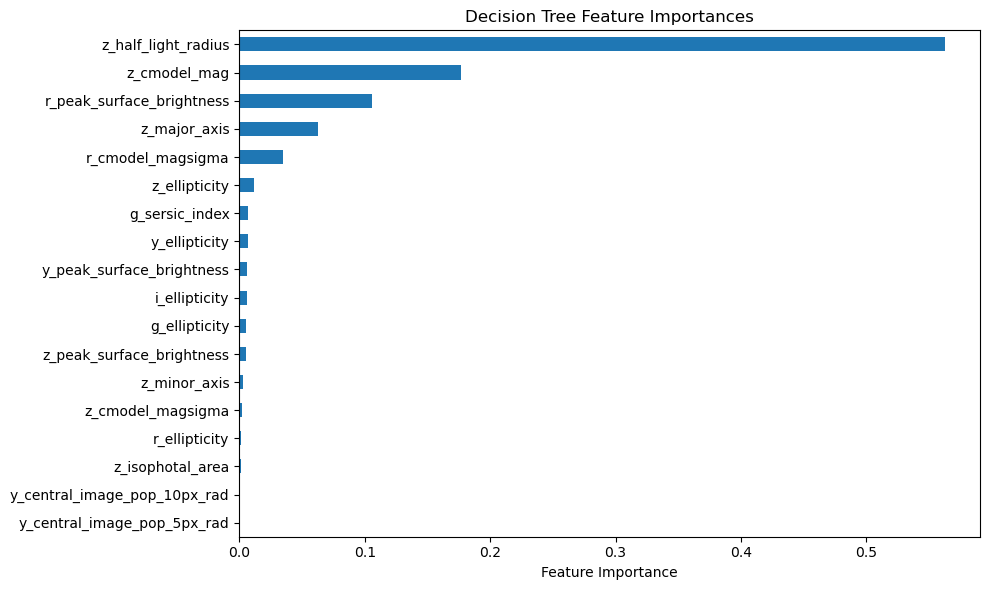

In [15]:
importances = pd.Series(dt.feature_importances_, index=final_features)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.sort_values().plot(kind='barh')
plt.xlabel('Feature Importance')
plt.title('Decision Tree Feature Importances')
plt.tight_layout()
plt.show()

# Models with Tabular Input

In [16]:
top5_features = [
    'z_half_light_radius',
    'z_cmodel_mag',
    'r_peak_surface_brightness',
    'z_major_axis',
    'r_cmodel_magsigma'
]

X_train_top5 = df_train[top5_features].values.astype(np.float64)
X_val_top5   = df_val[top5_features].values.astype(np.float64)
X_test_top5  = df_test[top5_features].values.astype(np.float64)

y_train = df_train['specz_redshift'].values
y_val   = df_val['specz_redshift'].values
y_test  = df_test['specz_redshift'].values


In [17]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_top5)  
X_val_sc   = scaler.transform(X_val_top5)
X_test_sc  = scaler.transform(X_test_top5)

In [18]:
def evaluate(name, y_true, y_pred):
    mse  = mean_squared_error(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    delta_z = np.abs(y_pred - y_true) / (1 + y_true)
    outlier_rate = np.mean(delta_z > 0.15) * 100
    print(f"{name:35s} | MSE: {mse:.4f} | MAE: {mae:.4f} | Outlier Rate: {outlier_rate:.2f}%")

In [19]:
models = {
    'Ridge':              Ridge(),
    'kNN':                KNeighborsRegressor(n_neighbors=5, n_jobs=-1),
    'Random Forest':      RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting':  GradientBoostingRegressor(n_estimators=100, random_state=42),
    'MLP':                MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42),
}

scaled_models   = {'Ridge', 'kNN', 'MLP'}

print("Validation Results\n" + "-"*70)
trained_models = {}
for name, model in models.items():
    X_tr = X_train_sc if name in scaled_models else X_train_top5
    X_vl = X_val_sc   if name in scaled_models else X_val_top5

    model.fit(X_tr, y_train)
    y_pred = model.predict(X_vl)
    evaluate(name, y_val, y_pred)
    trained_models[name] = model

Validation Results — Top 5 Features
----------------------------------------------------------------------
Ridge                               | MSE: 0.1822 | MAE: 0.2838 | Outlier Rate: 44.17%
kNN                                 | MSE: 0.0956 | MAE: 0.1609 | Outlier Rate: 15.43%
Random Forest                       | MSE: 0.0847 | MAE: 0.1492 | Outlier Rate: 13.83%
Gradient Boosting                   | MSE: 0.0873 | MAE: 0.1598 | Outlier Rate: 15.79%
MLP                                 | MSE: 0.0856 | MAE: 0.1520 | Outlier Rate: 14.25%


# Models with image input

In [ ]:
def load_image_split(path):
    with h5py.File(path, "r") as f:
        images = f['image'][:]                               
        labels = f['specz_redshift'][:].astype(np.float32)
        flags  = f['specz_flag_homogeneous'][:].astype(bool)

    images = images[flags]
    labels = labels[flags]

    return images, labels

images_train, y_train_img = load_image_split(TRAIN_PATH)
#images_val,   y_val_img   = load_image_split(VAL_PATH)
#images_test,  y_test_img  = load_image_split(TEST_PATH)

print(f"Train — images: {images_train.shape}, labels: {y_train_img.shape}")
#print(f"Val   — images: {images_val.shape},   labels: {y_val_img.shape}")
#print(f"Test  — images: {images_test.shape},  labels: {y_test_img.shape}")

In [ ]:
class GalaxyDataset(Dataset):
    def __init__(self, images, labels):
        self.images = torch.tensor(images, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

mean = images_train.mean(axis=(0, 2, 3), keepdims=True)  
std  = images_train.std(axis=(0, 2, 3), keepdims=True)
std  = np.where(std == 0, 1.0, std)                       

images_train_norm = (images_train - mean) / std
images_val_norm   = (images_val   - mean) / std          
images_test_norm  = (images_test  - mean) / std

train_dataset = GalaxyDataset(images_train_norm, y_train)
val_dataset   = GalaxyDataset(images_val_norm,   y_val)
test_dataset  = GalaxyDataset(images_test_norm,  y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=2)

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, in_channels=5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),                                       
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),                                       
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),                                     
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4))                           
        )
        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 128),          nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.regressor(self.features(x)).squeeze(1)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

def train_model(model, train_loader, val_loader, epochs=20, lr=1e-3):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
    criterion = nn.MSELoss()

    best_val_loss = float('inf')

    for epoch in range(epochs):
        model.train()
        train_losses = []
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                y_pred = model(X_batch)
                val_losses.append(criterion(y_pred, y_batch).item())

        train_loss = np.mean(train_losses)
        val_loss   = np.mean(val_losses)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'best_cnn.pt')

        print(f"Epoch {epoch+1:02d}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    print(f"\nBest Val Loss: {best_val_loss:.4f}")
    return model

cnn = SimpleCNN(in_channels=5)
cnn = train_model(cnn, train_loader, val_loader, epochs=20)


In [ ]:
def evaluate_cnn(model, loader, y_true):
    model.eval()
    preds = []
    with torch.no_grad():
        for X_batch, _ in loader:
            X_batch = X_batch.to(device)
            preds.append(model(X_batch).cpu().numpy())
    y_pred = np.concatenate(preds)

    mse  = mean_squared_error(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    delta_z = np.abs(y_pred - y_true) / (1 + y_true)
    outlier_rate = np.mean(delta_z > 0.15) * 100
    print(f"CNN — MSE: {mse:.4f} | MAE: {mae:.4f} | Outlier Rate: {outlier_rate:.2f}%")
    return y_pred

cnn.load_state_dict(torch.load('best_cnn.pt'))
y_pred_test = evaluate_cnn(cnn, test_loader, y_test)